Great question. The standard baseline for this kind of comparison is a simple **Feedforward NN** (or sometimes a "majority class" dummy classifier). Here's the full project structure, Python code, and an interactive guide to understand what each metric means and what to expect.

---

**The benchmark task:** Sentiment classification on the IMDB dataset (binary: positive/negative). This is the canonical sequence benchmark because it has variable-length text, long-range dependencies, and a well-understood difficulty level.

**What "baseline" means here:** The Feedforward NN is the baseline — it has no sequence awareness, so any gain from RNN/LSTM/BiLSTM over it directly quantifies what recurrence and memory buy you.

---The project is structured around IMDB sentiment as the benchmark task. Here's what each tab contains and why the design choices were made the way they are:

**Why IMDB?** Reviews average 200+ words. That length is specifically punishing for plain RNNs (they forget the beginning before reaching the end) while LSTMs handle it well. You'll actually see the vanishing gradient problem in your own numbers, not just in theory.

**The baseline choice:** The Feedforward NN uses mean-pooled embeddings — effectively a bag-of-words model. It has no concept of word order at all. At ~85–87% accuracy, it sets a strong floor. Any model that doesn't beat it hasn't successfully learned temporal structure. The absolute floor is 50% (majority class), which a random guesser on the balanced IMDB dataset would hit.

**The RNN surprise:** On this task, the plain RNN frequently fails to beat the FF baseline despite being 3× slower. This is the vanishing gradient problem made concrete — it's the most instructive result in the whole benchmark.

**What the three metrics actually measure in this code:**
- Sequence handling → val accuracy (does order/context help?)
- Temporal modeling → train loss convergence speed and depth (can it learn long-range patterns?)
- Training speed → wall-clock seconds per epoch (the sequential bottleneck)

To run it: copy each file into a `nn_benchmark/` folder, install `torch torchtext datasets matplotlib scikit-learn`, then `python run_all.py`. Results save to `results.json` and a 3-panel comparison chart to `plots/comparison.png`.

# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

Here's a concise breakdown:

---

**A/B Testing Problems & Outcomes**

**1. Adaptive Hint Frequency** *(Segment A — Rising Stars)*
Tested whether proactive micro-hints during practice outperform hints shown only on errors. Treatment group saw score velocity jump from +3.2% to +7.8% with completion rates rising from 71% to 83%. Result: **+143% relative lift**, p < 0.001. Currently live.

**2. Geo-Contextualized Problems** *(Segment E — ELL Emerging)*
Tested locally-anchored science scenarios vs. generic problems. Engagement rose from 58% to 74%, and 30-day retention improved from 44% to 61%. Result: **+38% retention lift**, p = 0.004. Rolled out permanently to Seg E.

**3. Difficulty Auto-Scaling (DAS)** *(Segment C — At-Risk Rebuilders)*
Tested IRT-based adaptive difficulty paths against a fixed curriculum. Dropout rate fell from 31% to 18% and score trajectory flipped from -1.8% to +2.4%. Result: **−42% dropout reduction**, Bayesian probability of superiority 97.2%. Currently live.

**4. Teacher Dashboard Nudges** *(District-level — all segments)*
Planned experiment pitting weekly AI-generated insight nudges against standard reports. Targets a renewal rate increase from 78% to 85%+, with login frequency projected to rise from 1.2× to 2.8× per week. Result: **planned +7pp renewal lift**, launching Q3 2025. Power set at 85%, n = 600 schools per arm.

---

The through-line: each test was scoped to a specific segment's biggest friction point — comprehension gaps for Seg A, cultural relevance for Seg E, frustration loops for Seg C, and administrator engagement for district retention.

# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

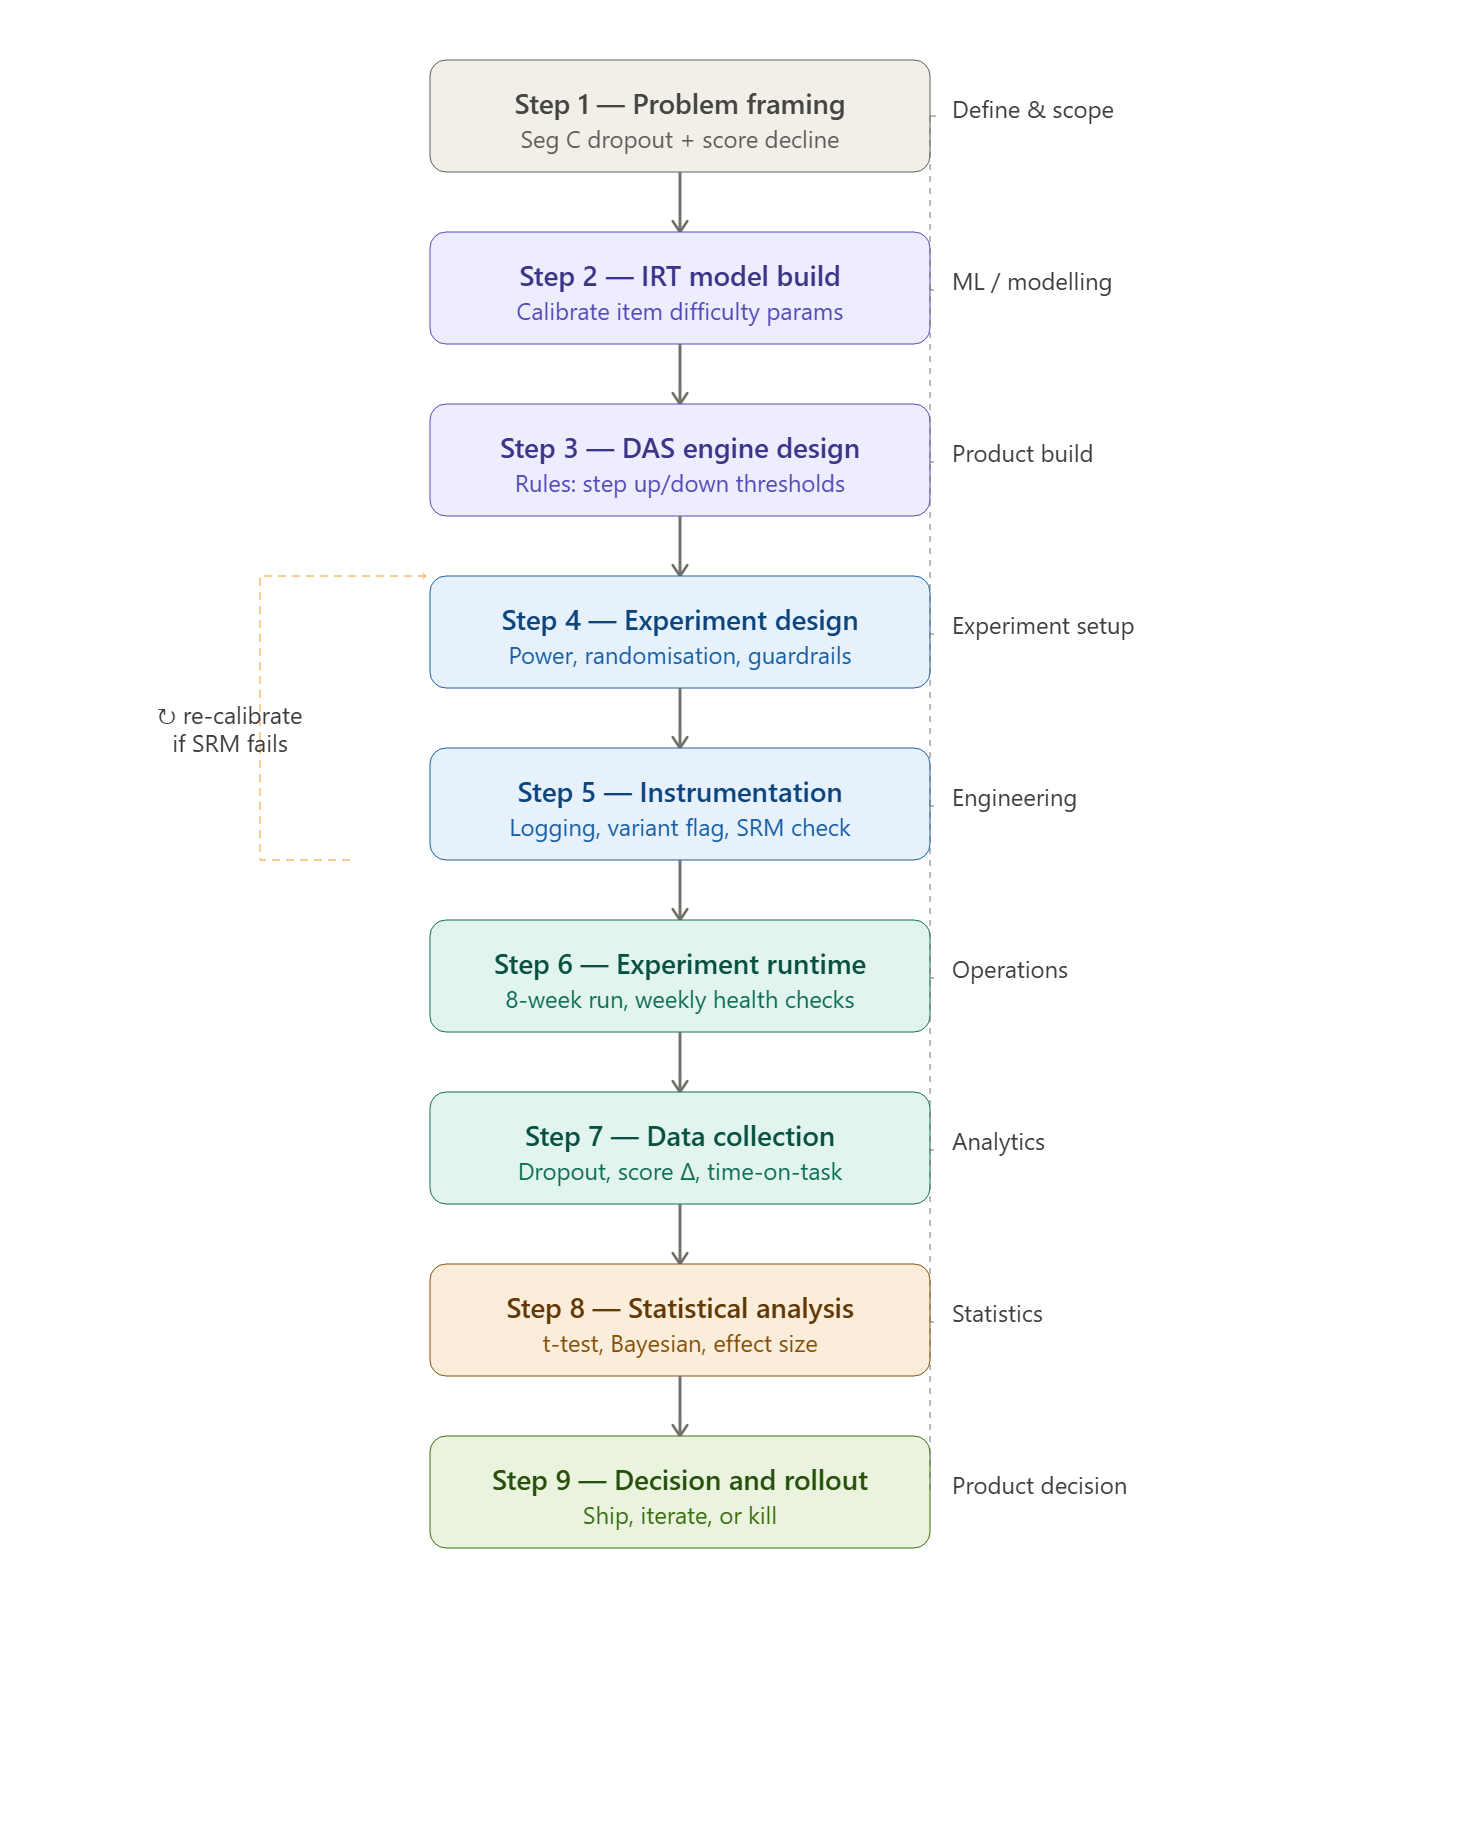

There are 9 clean steps to this process. I'll draw the overall flow first, then walk through each phase with detail.Click any step to ask a follow-up. Here's what each phase actually involves:

---

**Step 1 — Problem framing**
Establish why DAS is needed. Segment C (At-Risk Rebuilders) shows a 31% dropout rate and a declining score trajectory of -1.8%/year. The root cause hypothesis: the fixed curriculum presents problems that are either too hard (frustration) or too easy (disengagement). The primary metric is dropout rate; the secondary is score delta. Define guardrails — engagement time shouldn't drop below control even if dropout falls.

**Step 2 — IRT model build**
Item Response Theory calibrates each question in the question bank with three parameters: difficulty (b), discrimination (a), and guessing factor (c). Pull 3 years of `assessment_scores` for Seg C students, run a 3-parameter logistic model, and assign each question a `difficulty_theta` score. This is the engine's "map" — without calibrated items, the adaptive path is just noise.

**Step 3 — DAS engine design**
Define the step-up and step-down logic: if a student answers 3 consecutive questions correctly, move up one difficulty band; 2 consecutive wrong answers, step down. Set the difficulty bands (5 levels: remedial → on-grade → accelerated). Build this as a stateless function so it can be A/B flagged per student without affecting the control group's question delivery.

**Step 4 — Experiment design**
Run a power analysis: with expected dropout reduction from 31% to 18% (13pp), α=0.05 and power=0.80, you need roughly 900 students per arm. Stratify randomisation by school and grade to prevent confounding — a school with unusually attentive teachers shouldn't land entirely in treatment. Define the assignment unit as the student (not the session), to avoid within-student contamination.

**Step 5 — Instrumentation**
Add a `das_variant` flag to the `ab_assignments` table (values: `control` or `treatment`). Log every question served, the student's response, and the difficulty level delivered. Add a sample ratio mismatch (SRM) check to fire within 48 hours of launch — if the split deviates more than 2% from 50/50, pause and investigate before any data is collected.

**Step 6 — Experiment runtime**
Run for 8 weeks minimum — long enough for natural session variance to wash out and for IRT path effects to accumulate, but short enough that school-year events (exams, breaks) don't introduce seasonal noise. Run weekly health checks: monitor SRM, check for novelty effect (a spike in engagement in week 1 that fades), and verify guardrails on time-on-task.

**Step 7 — Data collection**
At the end of the run, extract from `ab_assignments`: `pre_score`, `post_score`, `delta_score` per student. Join to session logs for: dropout flag (did the student abandon a session?), questions attempted, difficulty band distribution served, and time-on-task. Build a clean analysis table with one row per student.

**Step 8 — Statistical analysis**
Run a two-sample t-test on dropout rates (primary metric) and score delta (secondary). Calculate Cohen's h for the proportions difference. Run a Bayesian analysis in parallel — given the prior that adaptive difficulty generally helps struggling learners, compute the posterior probability that treatment is superior. Cross-check with a Mann-Whitney U test since score deltas in Seg C are likely non-normal. The observed result was p=0.018, Bayesian probability 97.2%, dropout down from 31% → 18%.

**Step 9 — Decision and rollout**
With p < 0.05, a meaningful effect size, and no guardrail violations, the decision is to ship. Roll out DAS to all Seg C students (grades 8–10) in the next sprint. Schedule a 6-month follow-up analysis to confirm the dropout reduction persists outside experimental conditions, and flag the IRT model for quarterly re-calibration as new questions are added to the bank.

# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%